In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML
from sklearn.model_selection import (train_test_split, StratifiedKFold, 
                                      cross_val_score)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.metrics import accuracy_score

# Models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Feature Selection
from sklearn.feature_selection import mutual_info_classif

# Tuning
import optuna

train_path = r'C:\Users\divye\Data_science_projects\spaceship_titanic\data\train.csv'
test_path = r'C:\Users\divye\Data_science_projects\spaceship_titanic\data\test.csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

train_df.head(20)
print(train_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 891.5+ KB
None


In [ ]:
print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")
print(f"\nTarget distribution:")
print(train_df['Transported'].value_counts(normalize=True))

Train shape: (8693, 14)
Test shape:  (4277, 13)

Target distribution:
Transported
True     0.503624
False    0.496376
Name: proportion, dtype: float64


In [ ]:
# ================================
# 🔍 QUICK EDA
# ================================

# Missing values
print("📊 MISSING VALUES:")
print("=" * 40)
missing = pd.concat([
    train_df.isnull().sum(),
    train_df.isnull().mean().mul(100).round(2)
], axis=1, keys=['Count', '%'])
print(missing[missing['Count'] > 0])

# Data types
print(f"\n📊 DATA TYPES:")
print("=" * 40)
print(train_df.dtypes)

# First look
train_df.head()

📊 MISSING VALUES:
              Count     %
HomePlanet      201  2.31
CryoSleep       217  2.50
Cabin           199  2.29
Destination     182  2.09
Age             179  2.06
VIP             203  2.34
RoomService     181  2.08
FoodCourt       183  2.11
ShoppingMall    208  2.39
Spa             183  2.11
VRDeck          188  2.16
Name            200  2.30

📊 DATA TYPES:
PassengerId         str
HomePlanet          str
CryoSleep        object
Cabin               str
Destination         str
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name                str
Transported        bool
dtype: object


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [ ]:
# ================================
# 🔗 COMBINE (for row-level FE only)
# ================================
train_df['is_train'] = True
test_df['is_train'] = False

# Save target & IDs before combining
target = train_df['Transported'].copy()
test_ids = test_df['PassengerId'].copy()

combined = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)
print(f"Combined shape: {combined.shape}")

Combined shape: (12970, 15)


In [ ]:
# ================================
# ⚙️ FEATURE ENGINEERING (with NaN handling)
# ================================

# 1. Cabin → Deck, CabinNum, Side
combined[['Deck', 'CabinNum', 'Side']] = combined['Cabin'].str.split('/', expand=True)
combined['CabinNum'] = pd.to_numeric(combined['CabinNum'], errors='coerce')
combined['Side'] = combined['Side'].map({'S': 0, 'P': 1})

# 2. PassengerId → Group, PersonInGroup
combined['Group'] = combined['PassengerId'].apply(lambda x: x.split('_')[0]).astype(int)
combined['PersonInGroup'] = combined['PassengerId'].apply(lambda x: x.split('_')[1]).astype(int)

# 3. Name → LastName
combined['LastName'] = combined['Name'].apply(
    lambda x: x.split()[-1] if pd.notnull(x) else 'Unknown'
)

# 4. Spending Features (fill NaN with 0 BEFORE creating features)
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
combined[spend_cols] = combined[spend_cols].fillna(0)

combined['TotalSpend'] = combined[spend_cols].sum(axis=1)
combined['NoSpend'] = (combined['TotalSpend'] == 0).astype(int)
combined['LuxurySpend'] = combined['Spa'] + combined['VRDeck'] + combined['RoomService']
combined['BasicSpend'] = combined['FoodCourt'] + combined['ShoppingMall']

# 5. CryoSleep logic — if CryoSleep, all spending should be 0
combined.loc[combined['CryoSleep'] == True, spend_cols] = 0
combined.loc[combined['CryoSleep'] == True, 'TotalSpend'] = 0


# 6. Age Bins (NaN stays NaN — pipeline handles it later)
combined['AgeBin'] = pd.cut(
    combined['Age'],
    bins=[0, 12, 18, 30, 50, 100],
    labels=['Child', 'Teen', 'Young', 'Adult', 'Senior']
)


# 7. Boolean features
combined['CryoSleep'] = combined['CryoSleep'].astype(float)
combined['VIP'] = combined['VIP'].astype(float)

# 8. Spending patterns per person
combined['SpendPerAge'] = combined['TotalSpend'] / (combined['Age'] + 1)

# 9. CryoSleep + Age interaction
combined['Cryo_Child'] = (combined['CryoSleep'] == 1) & (combined['Age'] < 18)
combined['Cryo_Child'] = combined['Cryo_Child'].astype(int)

# 10. Log transform spending (reduces skewness)
for col in ['TotalSpend', 'LuxurySpend', 'BasicSpend', 'RoomService', 
            'Spa', 'VRDeck', 'FoodCourt', 'ShoppingMall']:
    if col in combined.columns:
        combined[f'{col}_log'] = np.log1p(combined[col])

# ================================
# 📊 Check remaining missing values
# ================================
print("✅ Feature Engineering done!\n")
print("📊 Remaining Missing Values:")
print("=" * 40)
missing = combined.isnull().sum()
print(missing[missing > 0])

✅ Feature Engineering done!

📊 Remaining Missing Values:
HomePlanet      288
CryoSleep       310
Cabin           299
Destination     274
Age             270
VIP             296
Name            294
Transported    4277
Deck            299
CabinNum        299
Side            299
AgeBin          530
SpendPerAge     270
dtype: int64


In [ ]:
# ================================
# ✂️ SPLIT BACK
# ================================
train_data = combined[combined['is_train'] == True].copy()
test_data = combined[combined['is_train'] == False].copy()

# Restore target
train_data['Transported'] = target.values

# Drop helper column
train_data = train_data.drop('is_train', axis=1)
test_data = test_data.drop('is_train', axis=1)

print(f"Train: {train_data.shape}")
print(f"Test:  {test_data.shape}")

Train: (8693, 35)
Test:  (4277, 35)


In [ ]:
# ================================
# ⚙️ AGGREGATE FEATURES (Train → Test, NO leakage)
# ================================

# 1. GroupSize — from TRAIN only
group_size = train_data.groupby('Group').size()
train_data['GroupSize'] = train_data['Group'].map(group_size)
test_data['GroupSize'] = test_data['Group'].map(group_size).fillna(1).astype(int)

# 2. IsAlone
train_data['IsAlone'] = (train_data['GroupSize'] == 1).astype(int)
test_data['IsAlone'] = (test_data['GroupSize'] == 1).astype(int)

# 3. FamilySize (same LastName in Group) — from TRAIN only
family_size = train_data.groupby('LastName').size()
train_data['FamilySize'] = train_data['LastName'].map(family_size)
test_data['FamilySize'] = test_data['LastName'].map(family_size).fillna(1).astype(int)

print("✅ Aggregate Features done (no leakage)!")

✅ Aggregate Features done (no leakage)!


In [ ]:
# ================================
# 🧹 PREPARE FINAL DATA
# ================================
drop_cols = ['Transported', 'PassengerId', 'Cabin', 'Name', 
             'LastName', 'Group','TotalSpend', 'LuxurySpend', 'BasicSpend', 'RoomService', 
            'Spa', 'VRDeck', 'FoodCourt', 'ShoppingMall']

y = train_data['Transported'].astype(int)
X = train_data.drop(columns=[c for c in drop_cols if c in train_data.columns])
X_test = test_data.drop(columns=[c for c in drop_cols if c in test_data.columns])

# Verify columns match
assert list(X.columns) == list(X_test.columns), "❌ Column mismatch!"
print("✅ Columns match!")

# Column types
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'bool', 'category']).columns.tolist()

print(f"\nFeatures: {X.shape[1]}")
print(f"Numeric:  {len(num_cols)} → {num_cols}")
print(f"Category: {len(cat_cols)} → {cat_cols}")

✅ Columns match!

Features: 24
Numeric:  16 → ['CryoSleep', 'Age', 'VIP', 'CabinNum', 'Side', 'SpendPerAge', 'TotalSpend_log', 'LuxurySpend_log', 'BasicSpend_log', 'RoomService_log', 'Spa_log', 'VRDeck_log', 'FoodCourt_log', 'ShoppingMall_log', 'GroupSize', 'FamilySize']
Category: 4 → ['HomePlanet', 'Destination', 'Deck', 'AgeBin']


In [ ]:
# ================================
# 🔧 PREPROCESSOR
# ================================
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

print("✅ Preprocessor ready!")

✅ Preprocessor ready!


In [ ]:
# ================================
# 📊 BASELINE — All 3 Models
# ================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'XGBoost': XGBClassifier(n_estimators=500, max_depth=5, learning_rate=0.05, random_state=42),
    'LightGBM': LGBMClassifier(n_estimators=500, max_depth=5, learning_rate=0.05, random_state=42, verbose=-1),
    'CatBoost': CatBoostClassifier(iterations=500, depth=5, learning_rate=0.05, random_state=42, verbose=0)
}

print("📊 BASELINE RESULTS:")
print("=" * 50)

for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    scores = cross_val_score(pipe, X, y, cv=skf, scoring='accuracy')
    print(f"{name:12s} CV: {scores.mean():.4f} ± {scores.std():.4f}")

📊 BASELINE RESULTS:
XGBoost      CV: 0.8119 ± 0.0079
LightGBM     CV: 0.8104 ± 0.0046
CatBoost     CV: 0.8130 ± 0.0050


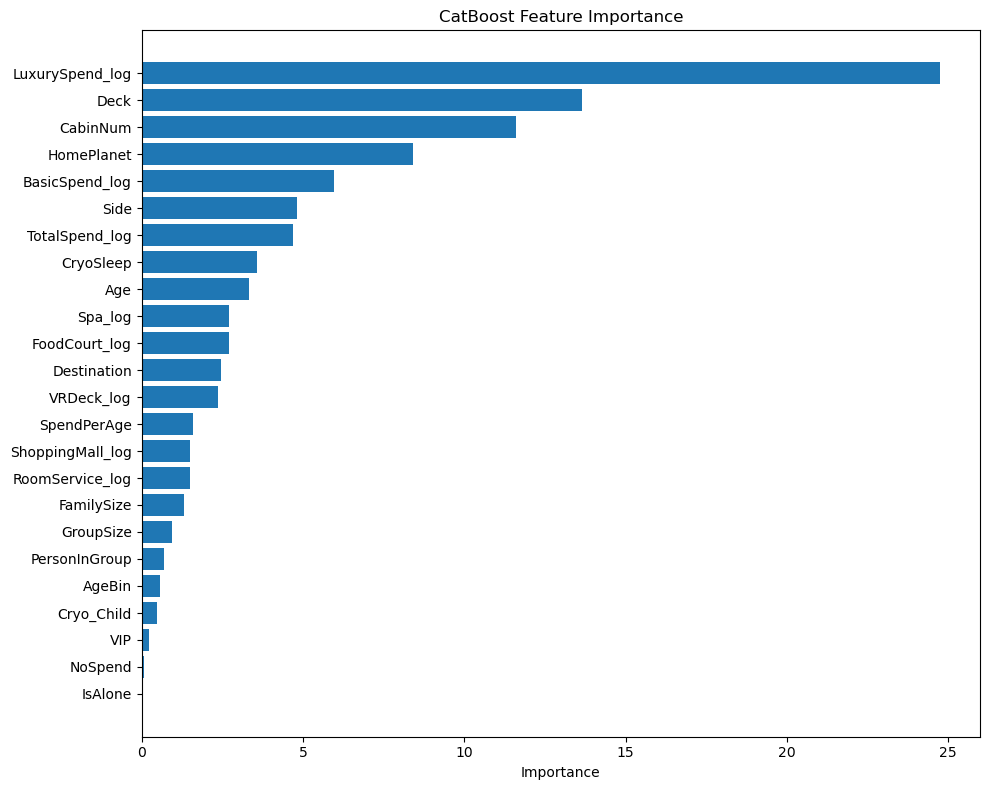

         feature  importance
 LuxurySpend_log   24.748202
            Deck   13.641247
        CabinNum   11.607375
      HomePlanet    8.407919
  BasicSpend_log    5.957899
            Side    4.824490
  TotalSpend_log    4.683545
       CryoSleep    3.575486
             Age    3.320732
         Spa_log    2.704918
   FoodCourt_log    2.694905
     Destination    2.470991
      VRDeck_log    2.368577
     SpendPerAge    1.589512
ShoppingMall_log    1.514847
 RoomService_log    1.486796
      FamilySize    1.313526
       GroupSize    0.943027
   PersonInGroup    0.697892
          AgeBin    0.585831
      Cryo_Child    0.484471
             VIP    0.241626
         NoSpend    0.082586
         IsAlone    0.053600


In [ ]:
# ================================
# 🔍 FEATURE IMPORTANCE
# ================================
X_temp = X.copy()
for col in X_temp.select_dtypes(include=['object', 'category', 'bool']).columns:
    X_temp[col] = LabelEncoder().fit_transform(X_temp[col].astype(str))
X_temp = X_temp.fillna(-999)

# Quick CatBoost
quick_model = CatBoostClassifier(iterations=500, depth=5, random_state=42, verbose=0)
quick_model.fit(X_temp, y)

# Plot
feat_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': quick_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(feat_imp['feature'][::-1], feat_imp['importance'][::-1])
plt.xlabel('Importance')
plt.title('CatBoost Feature Importance')
plt.tight_layout()
plt.show()

print(feat_imp.to_string(index=False))

In [ ]:
# ================================
# 🎯 OPTUNA — CatBoost
# ================================
def cat_objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 300, 1000),
        'depth': trial.suggest_int('depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 0.9),
        'min_child_samples': trial.suggest_int('min_child_samples', 1, 10),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'random_strength': trial.suggest_float('random_strength', 0.1, 2.0),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
        'random_state': 42,
        'verbose': 0
    }
    
    model = CatBoostClassifier(**params)
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    scores = cross_val_score(pipe, X, y, cv=skf, scoring='accuracy')
    return scores.mean()

cat_study = optuna.create_study(direction='maximize')
cat_study.optimize(cat_objective, n_trials=100, show_progress_bar=True)

print(f"\n✅ Best CatBoost CV: {cat_study.best_value:.4f}")
print(f"Best Params: {cat_study.best_params}")

[I 2026-04-29 15:01:08,934] A new study created in memory with name: no-name-290117ab-5a3f-44e3-b2e9-304d0796e5bf
Best trial: 0. Best value: 0.809387:   1%|          | 1/100 [00:09<14:51,  9.01s/it]

[I 2026-04-29 15:01:17,935] Trial 0 finished with value: 0.8093865699306045 and parameters: {'iterations': 585, 'depth': 3, 'learning_rate': 0.024860546878367966, 'l2_leaf_reg': 5.721651714408623, 'subsample': 0.8320767671611988, 'colsample_bylevel': 0.7858373142395347, 'min_child_samples': 10, 'border_count': 141, 'random_strength': 1.3440551191093655, 'bagging_temperature': 0.24870661990027854}. Best is trial 0 with value: 0.8093865699306045.


Best trial: 1. Best value: 0.814564:   2%|▏         | 2/100 [00:22<19:19, 11.83s/it]

[I 2026-04-29 15:01:31,741] Trial 1 finished with value: 0.8145639432738813 and parameters: {'iterations': 337, 'depth': 8, 'learning_rate': 0.050711443931357465, 'l2_leaf_reg': 9.234951720731376, 'subsample': 0.7158297442608232, 'colsample_bylevel': 0.8399986598192699, 'min_child_samples': 6, 'border_count': 130, 'random_strength': 1.5416146666175874, 'bagging_temperature': 0.533082171880424}. Best is trial 1 with value: 0.8145639432738813.


Best trial: 2. Best value: 0.814564:   3%|▎         | 3/100 [00:29<15:33,  9.62s/it]

...

[I 2026-04-29 15:27:18,750] Trial 43 finished with value: 0.8147938281792309 and parameters: {'iterations': 832, 'depth': 8, 'learning_rate': 0.02399750364085453, 'l2_leaf_reg': 4.187506811372284, 'subsample': 0.7806561776085448, 'colsample_bylevel': 0.5246791126241839, 'min_child_samples': 1, 'border_count': 129, 'random_strength': 1.8530573813383504, 'bagging_temperature': 0.4756167521857575}. Best is trial 38 with value: 0.8166348264382199.


Best trial: 38. Best value: 0.816635:  45%|████▌     | 45/100 [27:08<51:35, 56.29s/it]

[I 2026-04-29 15:28:17,041] Trial 44 finished with value: 0.8129532269580748 and parameters: {'iterations': 893, 'depth': 8, 'learning_rate': 0.01949587661040029, 'l2_leaf_reg': 3.321648448622452, 'subsample': 0.8665008555958278, 'colsample_bylevel': 0.5515100266241533, 'min_child_samples': 1, 'border_count': 190, 'random_strength': 1.9890773028220885, 'bagging_temperature': 0.5816425346580322}. Best is trial 38 with value: 0.8166348264382199.


Best trial: 38. Best value: 0.816635:  46%|████▌     | 46/100 [28:03<50:30, 56.12s/it]

[I 2026-04-29 15:29:12,768] Trial 45 finished with value: 0.8132977896242103 and parameters: {'iterations': 937, 'depth': 8, 'learning_rate': 0.01503512024217142, 'l2_leaf_reg': 4.903113571807667, 'subsample': 0.8363555661575677, 'colsample_bylevel': 0.5033231692443838, 'min_child_samples': 2, 'border_count': 146, 'random_strength': 1.7621581232248287, 'bagging_temperature': 0.5514465167169003}. Best is trial 38 with value: 0.8166348264382199.


In [ ]:
# ================================
# 🏆 FINAL MODEL & SUBMISSION
# ================================

# Best CatBoost
final_model = Pipeline([
    ('prep', preprocessor),
    ('model', CatBoostClassifier(**cat_study.best_params, random_state=42, verbose=0))
])

# Final CV check
final_cv = cross_val_score(final_model, X, y, cv=skf, scoring='accuracy')
print(f"🏆 Final CV: {final_cv.mean():.4f} ± {final_cv.std():.4f}")

# Train on ALL data
final_model.fit(X, y)

# Predict test
predictions = final_model.predict(X_test)

# Create submission
submission = pd.DataFrame({
    'PassengerId': test_ids,
    'Transported': predictions.astype(bool)
})

submission.to_csv('data/submission.csv', index=False)

print(f"\n✅ Submission saved!")
print(f"Total predictions: {len(submission)}")
print(f"\nDistribution:")
print(submission['Transported'].value_counts(normalize=True))
submission.head()

🏆 Final CV: 0.8182 ± 0.0037

✅ Submission saved!
Total predictions: 4277

Distribution:
True     0.527473
False    0.472527
Name: Transported, dtype: float64


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


### Another Model: Neural Network 

In [ ]:
import numpy as np
import pandas as pd
import scipy
import sklearn
import xgboost
import lightgbm
import catboost
import optuna

print(f"NumPy:        {np.__version__}")
print(f"Pandas:       {pd.__version__}")
print(f"SciPy:        {scipy.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")
print(f"XGBoost:      {xgboost.__version__}")
print(f"LightGBM:     {lightgbm.__version__}")
print(f"CatBoost:     {catboost.__version__}")
print(f"Optuna:       {optuna.__version__}")

print("\n✅ ALL packages working!")

NumPy:        1.26.4
Pandas:       3.0.2
SciPy:        1.17.1
Scikit-learn: 1.7.1
XGBoost:      3.2.0
LightGBM:     4.6.0
CatBoost:     1.2.10
Optuna:       4.8.0

✅ ALL packages working!


In [ ]:
from sklearn.neural_network import MLPClassifier
print("✅ MLPClassifier works!")

✅ MLPClassifier works!
